# El Niño and the seasonal cycle of West Coast sea level

Monthly mean sea level at San Diego peaks in late summer, when the warm upper ocean
expands and raises the sea surface (steric height). Moving north along the coast, the
seasonal maximum shifts toward winter, where lower atmospheric pressure, onshore winds,
and storm-driven ocean response control the cycle.

El Niño adds a separate signal: during a strong event, elevated coastal sea level
propagates poleward along the eastern boundary and typically peaks between October and
February. Whether that pulse lands on top of a station's seasonal maximum or months
after it depends on latitude. In San Diego the seasonal peak has already passed by
mid-winter; in northern California and Oregon the two maxima can coincide.

This notebook builds the plot that shows this: a two-year seasonal cycle for each
station, with the 1982–83, 1997–98, 2015–16, and 2023–24 El Niño winters drawn over
the climatology — and the current 2026–27 event, still in progress, drawn in red as
far as the data reach. Everything is in centimeters; the wave and total-water-level
work later in the course stays metric too.

Data: daily tide gauge records from the
[University of Hawaii Sea Level Center](https://uhslc.soest.hawaii.edu/data/),
extended to the present with NOAA CO-OPS monthly means in section 6. You start with
San Diego (UHSLC station 569), then repeat the analysis along a ten-station transect
from San Diego to Astoria.

In [1]:
import json
from pathlib import Path
from urllib.request import urlopen, urlretrieve
from urllib.error import HTTPError, URLError

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name in ("notebooks", "reference"):
    PROJECT_ROOT = PROJECT_ROOT.parent
assert (PROJECT_ROOT / "README.md").exists(), "Open the course project folder first."

UHSLC_RAW = PROJECT_ROOT / "data" / "raw" / "uhslc"
UHSLC_RAW.mkdir(parents=True, exist_ok=True)
print("UHSLC raw folder:", UHSLC_RAW)

UHSLC raw folder: /Users/holden/Documents/Scripps/Teaching/Climate_science_bootcamp/data/raw/uhslc


## 1. The station transect

Each UHSLC daily file is named `d<station id>.nc`. Active stations sit in the
fast-delivery archive (`fast/daily`, updated within weeks of collection); stations
whose feed to the archive has ended live in the research-quality archive
(`rqds/pacific/daily`) with a version letter in the filename (`d555a.nc`). The helper
below tries both, and skips the download when the file is already on disk, so the raw
folder stays reproducible: one file per station, exactly as the provider served it.

Record spans differ. San Francisco starts in 1897 and San Diego in 1906; Humboldt Bay
only in 1977. Five of the ten records stop between 2021 and 2024 — remember that when
we get to the current event.

In [2]:
# South to north. File names as distributed by UHSLC.
STATIONS = [
    {"file": "d569.nc",  "name": "San Diego"},
    {"file": "d554.nc",  "name": "La Jolla"},
    {"file": "d567a.nc", "name": "Los Angeles"},
    {"file": "d565a.nc", "name": "Port San Luis"},
    {"file": "d555a.nc", "name": "Monterey"},
    {"file": "d551.nc",  "name": "San Francisco"},
    {"file": "d576a.nc", "name": "Humboldt Bay"},
    {"file": "d556.nc",  "name": "Crescent City"},
    {"file": "d592.nc",  "name": "South Beach (Newport, OR)"},
    {"file": "d572a.nc", "name": "Astoria"},
]

UHSLC_BASE = "https://uhslc.soest.hawaii.edu/data/netcdf"
ARCHIVES = ["fast/daily", "rqds/pacific/daily"]


def fetch_station(filename):
    """Download one UHSLC daily NetCDF file into data/raw/uhslc, if not already there."""
    target = UHSLC_RAW / filename
    if target.exists():
        return target
    for archive in ARCHIVES:
        url = f"{UHSLC_BASE}/{archive}/{filename}"
        try:
            urlretrieve(url, target)
            print(f"downloaded {filename} from {archive}")
            return target
        except HTTPError:
            continue
    raise FileNotFoundError(f"{filename} not found in any UHSLC archive")


sd_path = fetch_station("d569.nc")
print(sd_path, f"({sd_path.stat().st_size/1e3:.0f} kB)")

/Users/holden/Documents/Scripps/Teaching/Climate_science_bootcamp/data/raw/uhslc/d569.nc (109 kB)


## 2. Load San Diego and look at the whole record

The file follows CF conventions: `sea_level` in millimeters relative to the station
datum, one value per day, with a `record_id` dimension of length 1 that we squeeze
out. We work in centimeters.

San Diego (32.71°N): 1906-01-22 to 2026-06-30
43085 valid days, 905 gaps


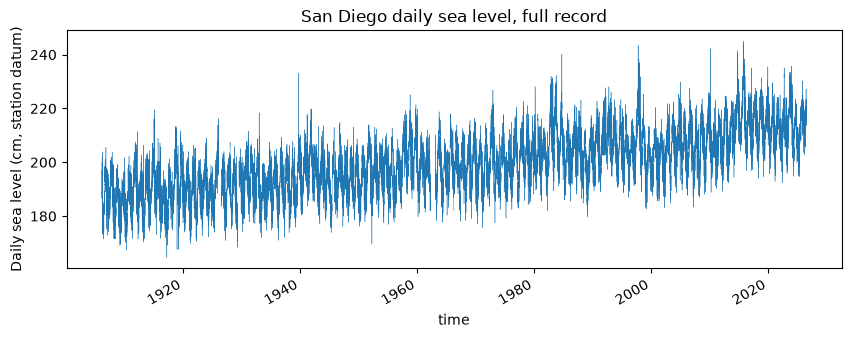

In [3]:
MM_TO_CM = 0.1


def load_daily(path):
    """Return daily sea level as a pandas Series in cm, plus station metadata."""
    with xr.open_dataset(path) as ds:
        name = ds["station_name"].values.astype(str).item()
        lat = float(ds["lat"].values.squeeze())
        daily = ds["sea_level"].squeeze("record_id", drop=True).to_series() * MM_TO_CM
    return daily, name, lat


sd_daily, sd_name, sd_lat = load_daily(sd_path)
print(f"{sd_name} ({sd_lat:.2f}°N): {sd_daily.index[0].date()} to {sd_daily.index[-1].date()}")
print(f"{sd_daily.notna().sum()} valid days, {sd_daily.isna().sum()} gaps")

fig, ax = plt.subplots(figsize=(10, 3.5))
sd_daily.plot(ax=ax, lw=0.3, color="tab:blue")
ax.set_ylabel("Daily sea level (cm, station datum)")
ax.set_title(f"{sd_name} daily sea level, full record")
plt.show()

Two things to notice before averaging anything: the record has gaps (the line above
skips them), and the whole cloud drifts upward across the century. That drift is
relative sea level rise, and it matters here: it is comparable in size to the signals
we want to compare, and it would make a 2015 winter look higher than a 1997 winter for
reasons that have nothing to do with El Niño. So the processing chain removes it.

## 3. From daily data to a detrended monthly series

Three steps, in order:

1. **Monthly means.** Day-to-day wiggles are tides, storms, and eddies; the monthly
   mean leaves the seasonal cycle plus interannual signals. A month with fewer than
   15 valid days becomes NaN rather than a poorly sampled average.
2. **A 3-month running mean**, tolerant of single missing months, to knock down
   month-to-month noise.
3. **Remove the linear trend** over the full record, which takes out sea level rise
   (and, at some stations, vertical land motion) and centers the series on zero.

In [4]:
MIN_DAYS_PER_MONTH = 15


def monthly_means(daily):
    """Calendar-month means, NaN where fewer than MIN_DAYS_PER_MONTH valid days."""
    grouped = daily.resample("MS")   # "MS" = group by month, stamp at month start
    monthly = grouped.mean()
    # a month with only a handful of real observations is not a trustworthy average
    monthly[grouped.count() < MIN_DAYS_PER_MONTH] = np.nan
    return monthly


def smooth_3month(monthly):
    """Centered 3-month running mean; a value needs at least 2 of the 3 months."""
    return monthly.rolling(3, center=True, min_periods=2).mean()


def remove_trend(monthly):
    """Subtract the least-squares line through the valid points. Returns
    (detrended series in cm, trend in mm/yr)."""
    # time axis in fractional years, stamped at each month's center
    years = monthly.index.year + (monthly.index.month - 0.5) / 12
    valid = monthly.notna()          # polyfit cannot handle NaN months
    slope, intercept = np.polyfit(years[valid], monthly[valid], 1)
    detrended = monthly - (slope * years + intercept)
    return detrended, slope * 10     # slope is cm/yr; x10 converts to mm/yr


def process_station(monthly):
    """Monthly series in cm -> (detrended smoothed series, trend in mm/yr)."""
    return remove_trend(smooth_3month(monthly))


sd_monthly = monthly_means(sd_daily)
sd_sl, sd_trend = process_station(sd_monthly)
print(f"{sd_name} linear trend: {sd_trend:.1f} mm/yr")

San Diego linear trend: 2.2 mm/yr


San Diego's trend should come out near the 2.2 mm/yr NOAA reports for this station.
If your number is wildly different, stop and debug before going on.

## 4. Seasonal climatology and the two-year window

The seasonal cycle is the mean of the detrended series for each calendar month, over
the whole record. An El Niño event develops during one calendar year and peaks in the
winter that straddles the year boundary — the 1997–98 event peaked between November
1997 and February 1998 — so a January–December plot would cut every event in half.
Instead we use a 24-month axis, January of the onset year through December of the
following year, and tile the climatology twice for reference.

Event onset years and line styles live in one place so they are easy to change. The
three strongest events of the tide gauge era (1982–83, 1997–98, 2015–16) are black;
2023–24, a strong event by tropical indices with a milder coastal signal, is gray;
the 2026–27 event now in progress runs red until the data end.

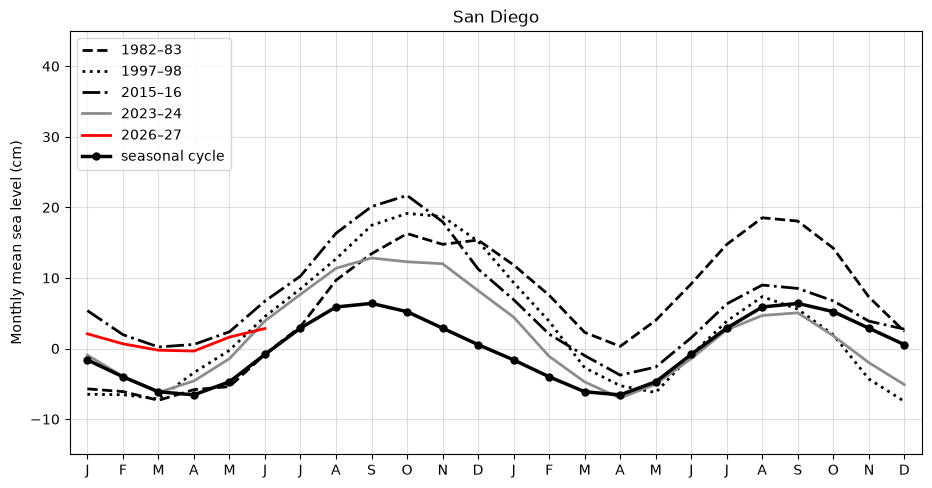

seasonal range: 13.0 cm, max in month 9, min in month 4
1982–83: peak departure from seasonal cycle +14.8 cm in 1982-12
1997–98: peak departure from seasonal cycle +15.8 cm in 1997-11
2015–16: peak departure from seasonal cycle +16.5 cm in 2015-10
2023–24: peak departure from seasonal cycle +9.1 cm in 2023-11
2026–27: peak departure from seasonal cycle +6.3 cm in 2026-05


In [5]:
# (onset year, label, line style) — edit this list to add or drop events
EVENTS = [
    (1982, "1982–83", dict(color="k", ls="--", lw=2)),
    (1997, "1997–98", dict(color="k", ls=":", lw=2)),
    (2015, "2015–16", dict(color="k", ls="-.", lw=2)),
    (2023, "2023–24", dict(color="0.55", ls="-", lw=2)),
    (2026, "2026–27", dict(color="r", ls="-", lw=2)),
]


def seasonal_climatology(sl):
    """Mean of the detrended series for each calendar month, full record. 12 values."""
    return sl.groupby(sl.index.month).mean()


def two_year_window(sl, onset_year):
    """The 24 monthly values from Jan(onset_year) through Dec(onset_year+1)."""
    # ask the series for exactly these 24 month-starts; months outside the
    # record come back as NaN, so truncated events simply stop plotting
    idx = pd.date_range(f"{onset_year}-01-01", periods=24, freq="MS")
    return sl.reindex(idx).to_numpy()


def plot_two_year_cycle(ax, sl, title):
    months = np.arange(1, 25)
    clim = seasonal_climatology(sl)
    for onset, label, style in EVENTS:
        window = two_year_window(sl, onset)
        if np.isnan(window).all():
            continue  # station record ends before this event
        ax.plot(months, window, label=label, **style)
    # the 12-month climatology drawn twice, so both winters have a reference
    ax.plot(months, np.tile(clim.to_numpy(), 2), "k-o", lw=2.5, ms=5,
            markerfacecolor="k", label="seasonal cycle", zorder=2)
    ax.set_xticks(months)
    ax.set_xticklabels(list("JFMAMJJASOND") * 2)
    ax.set_xlim(0.5, 24.5)
    ax.set_ylim(-15, 45)
    ax.set_title(title)
    ax.grid(alpha=0.4)


fig, ax = plt.subplots(figsize=(11, 5.5))
plot_two_year_cycle(ax, sd_sl, sd_name)
ax.set_ylabel("Monthly mean sea level (cm)")
ax.legend(loc="upper left")
plt.show()

clim = seasonal_climatology(sd_sl)
print(f"seasonal range: {clim.max() - clim.min():.1f} cm, "
      f"max in month {clim.idxmax()}, min in month {clim.idxmin()}")
for onset, label, _ in EVENTS:
    excess = two_year_window(sd_sl, onset) - np.tile(clim.to_numpy(), 2)
    if np.isnan(excess).all():
        continue
    imax = int(np.nanargmax(excess))
    when = f"{onset + imax // 12}-{imax % 12 + 1:02d}"
    print(f"{label}: peak departure from seasonal cycle "
          f"{np.nanmax(excess):+.1f} cm in {when}")

Read the San Diego panel before moving on. The seasonal cycle peaks in September and
falls through the winter. The three big past El Niño winters sit 10–16 cm above it
from October into spring — after the seasonal maximum has passed, so the two effects
partly offset. The events differ from each other, too: 1982–83 stayed high through
the following summer, 2015–16 peaked earlier in the fall than 1997–98, and gray
2023–24 — as strong as the others by tropical indices — reached only about half their
departure here (+9 cm against +15 to +17 cm). Composites are averages over messy
individuals, and the mess is part of the story. The red curve is where 2026–27
stands so far.

## 5. The full transect

Now repeat the same construction for all ten stations, north at the top. The series
are detrended and zero-centered, so one common axis in centimeters works everywhere.

One data-health catch first (this is why notebook 07 exists): the San Francisco
fast-delivery file contains a gauge malfunction from January through July 2024 —
readings drift up to ~25 cm high with gappy coverage. NOAA's *verified* product
withheld exactly those months, which is how cross-checking the two sources found the
problem; the fast-delivery stream's lighter quality control let them through. We mask
them before processing.

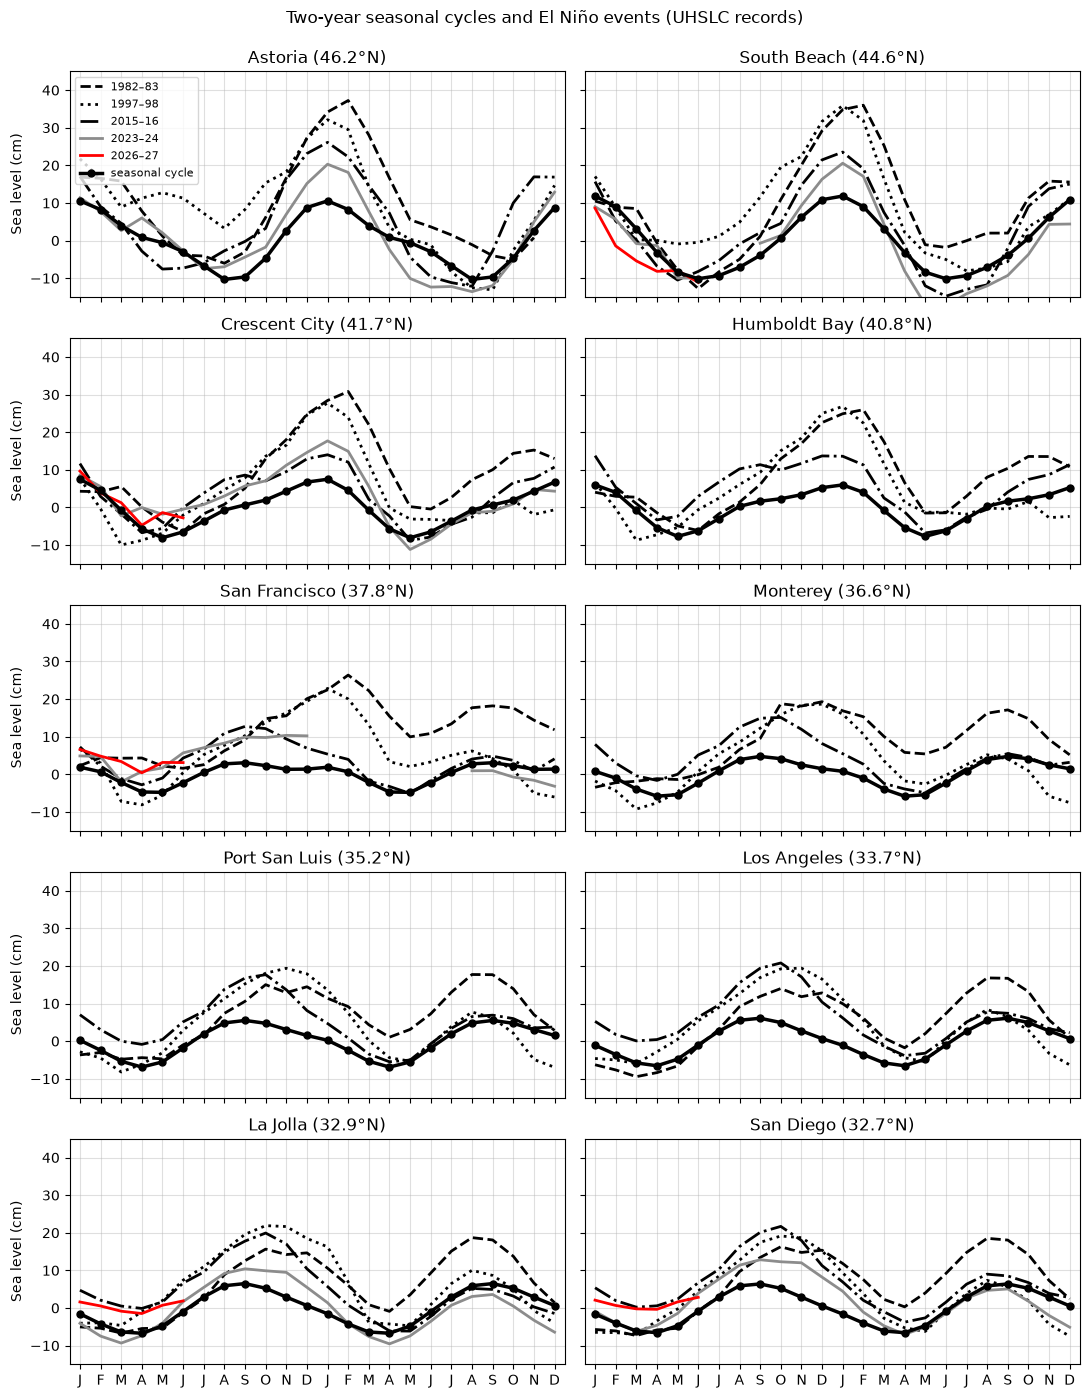

Station summary, north to south:
  station                      lat  clim max  range (cm)  trend (mm/yr)  record ends
  Astoria                     46.2   month 1        20.9           -0.1      2024-12
  South Beach                 44.6   month 1        22.0            1.5      2026-06
  Crescent City               41.7   month 1        15.6           -0.8      2026-06
  Humboldt Bay                40.8   month 1        13.7            4.6      2021-12
  San Francisco               37.8   month 9         7.9            2.0      2026-06
  Monterey                    36.6   month 9        10.6            1.7      2021-12
  Port San Luis               35.2   month 9        12.4            1.0      2021-12
  Los Angeles                 33.7   month 9        12.6            1.1      2021-12
  La Jolla                    32.9   month 9        13.2            2.0      2026-06
  San Diego                   32.7   month 9        13.0            2.2      2026-06


In [6]:
# Months present in the UHSLC fast-delivery file but withheld from NOAA's
# verified product (San Francisco gauge malfunction, Jan-Jul 2024).
BAD_MONTHS = {"d551.nc": pd.date_range("2024-01-01", "2024-07-01", freq="MS")}

records = []
for station in STATIONS:
    path = fetch_station(station["file"])
    daily, name, lat = load_daily(path)
    monthly = monthly_means(daily)
    monthly[monthly.index.isin(BAD_MONTHS.get(station["file"], []))] = np.nan
    sl, trend = process_station(monthly)
    records.append({"file": station["file"], "name": name, "lat": lat,
                    "monthly": monthly, "sl": sl, "trend": trend})

records.sort(key=lambda r: r["lat"], reverse=True)  # north at the top, like a map

fig, axes = plt.subplots(5, 2, figsize=(11, 14), sharex=True, sharey=True)
for ax, rec in zip(axes.flat, records):
    plot_two_year_cycle(ax, rec["sl"], f"{rec['name']} ({rec['lat']:.1f}°N)")
# legend from a fast-delivery station so the 2026-27 entry is included
handles, labels = axes.flat[1].get_legend_handles_labels()
axes.flat[0].legend(handles, labels, loc="upper left", fontsize=8)
for ax in axes[:, 0]:
    ax.set_ylabel("Sea level (cm)")
fig.suptitle("Two-year seasonal cycles and El Niño events (UHSLC records)", y=0.995)
fig.tight_layout()
plt.show()

print("Station summary, north to south:")
print(f"  {'station':<26} {'lat':>5} {'clim max':>9} {'range (cm)':>11} "
      f"{'trend (mm/yr)':>14} {'record ends':>12}")
for rec in records:
    clim = seasonal_climatology(rec["sl"])
    ends = rec["monthly"].last_valid_index().strftime("%Y-%m")
    print(f"  {rec['name']:<26} {rec['lat']:5.1f} {'month ' + str(clim.idxmax()):>9} "
          f"{clim.max() - clim.min():11.1f} {rec['trend']:14.1f} {ends:>12}")

Half the transect has no red curve. That is an artifact of the archive, not of the
ocean: Los Angeles, Port San Luis, Monterey, and Humboldt Bay left the UHSLC
research-quality stream after 2021 and Astoria after 2024, but NOAA still operates
every one of those gauges. The fast-delivery stations also lag the present by a month
or two. To watch the 2026–27 event develop, we need a second source.

## 6. Bringing every station up to the present with NOAA CO-OPS

NOAA CO-OPS serves verified monthly mean sea level for all ten gauges through its
[data API](https://api.tidesandcurrents.noaa.gov/api/prod/), usually within a couple
of weeks of month end. Two things need care:

- **Datums can differ.** CO-OPS heights need not sit on the same station datum as the
  UHSLC files, so each station gets a constant offset, estimated as the median
  difference over the months both sources share. For these ten the offset comes out
  near zero — UHSLC receives US records from NOAA on the same datum — but the scatter
  column is the check that each station pairing is right; more than a centimeter or
  two would mean a mismatch.
- **The current month is incomplete.** For August-to-date we average the preliminary
  6-minute feed. That point is provisional (partial month, unverified data) and is
  drawn as an open circle.

The UHSLC file stays the archival source; CO-OPS only supplies the recent tail.

In [7]:
COOPS_IDS = {  # UHSLC file -> NOAA CO-OPS station id
    "d569.nc": "9410170", "d554.nc": "9410230", "d567a.nc": "9410660",
    "d565a.nc": "9412110", "d555a.nc": "9413450", "d551.nc": "9414290",
    "d576a.nc": "9418767", "d556.nc": "9419750", "d592.nc": "9435380",
    "d572a.nc": "9439040",
}
COOPS_API = "https://api.tidesandcurrents.noaa.gov/api/prod/datagetter"
TODAY = pd.Timestamp.today()


def coops_request(station_id, product, begin, end):
    url = (f"{COOPS_API}?product={product}&begin_date={begin}&end_date={end}"
           f"&datum=STND&station={station_id}&time_zone=GMT&units=metric&format=json")
    with urlopen(url, timeout=60) as response:
        payload = json.load(response)
    return payload.get("data", [])


def fetch_coops_monthly(station_id):
    """Verified monthly mean sea level since 2017, in cm on the CO-OPS datum."""
    rows = coops_request(station_id, "monthly_mean", "20170101", TODAY.strftime("%Y%m%d"))
    idx = pd.to_datetime([f"{r['year']}-{int(r['month']):02d}-01" for r in rows])
    return pd.Series([float(r["MSL"]) * 100 for r in rows], index=idx)


def fetch_coops_month_to_date(station_id):
    """Provisional mean of the current month's preliminary 6-minute data, in cm.
    Returns None when the month has fewer than 7 days so far."""
    rows = coops_request(station_id, "water_level",
                         TODAY.strftime("%Y%m01"), TODAY.strftime("%Y%m%d"))
    values = [float(r["v"]) for r in rows if r.get("v")]
    if len(values) < 7 * 240:  # 240 six-minute samples per day
        return None
    return pd.Series([np.mean(values) * 100],
                     index=[pd.Timestamp(TODAY.strftime("%Y-%m-01"))])


def extend_with_coops(monthly, station_id):
    """Append offset-adjusted CO-OPS months after the UHSLC record ends. Returns
    (combined monthly series, diagnostics dict)."""
    coops = fetch_coops_monthly(station_id)
    partial = fetch_coops_month_to_date(station_id)
    if partial is not None:
        coops = pd.concat([coops, partial])
    # the datum difference between sources is a constant, so the median
    # difference over shared months estimates it robustly
    both = pd.concat([monthly, coops], axis=1, keys=["uhslc", "coops"]).dropna()
    diff = both["uhslc"] - both["coops"]
    offset = diff.median()
    tail = coops[coops.index > monthly.last_valid_index()] + offset
    combined = pd.concat([monthly[: monthly.last_valid_index()], tail])
    diagnostics = {"overlap_months": len(diff), "offset_cm": offset,
                   "scatter_cm": diff.std(),
                   "last_month": combined.index[-1].strftime("%Y-%m"),
                   "partial_last": partial is not None}
    return combined, diagnostics


print(f"  {'station':<26} {'overlap':>7} {'offset (cm)':>12} {'scatter (cm)':>13} {'through':>8}")
for rec in records:
    try:
        combined, diag = extend_with_coops(rec["monthly"], COOPS_IDS[rec["file"]])
        rec["sl_ext"], rec["trend_ext"] = process_station(combined)
        rec["partial_last"] = diag["partial_last"]
        print(f"  {rec['name']:<26} {diag['overlap_months']:>7} {diag['offset_cm']:>12.1f} "
              f"{diag['scatter_cm']:>13.1f} {diag['last_month']:>8}")
    except (HTTPError, URLError, TimeoutError) as err:
        rec["sl_ext"], rec["partial_last"] = rec["sl"], False
        print(f"  {rec['name']:<26} CO-OPS unavailable ({err}); UHSLC record only")

  station                    overlap  offset (cm)  scatter (cm)  through


  Astoria                         96         -0.0           0.2  2026-08


  South Beach                    110         -0.1           0.5  2026-08


  Crescent City                  114         -0.0           0.2  2026-08


  Humboldt Bay                    60         -0.0           0.2  2026-08


...

  Monterey                        60          0.0           0.1  2026-08


  Port San Luis                   60          0.0           0.1  2026-08


  Los Angeles                     60          0.0           0.1  2026-08


  La Jolla                       113          0.0           0.1  2026-08


  San Diego                      114         -0.0           0.1  2026-08


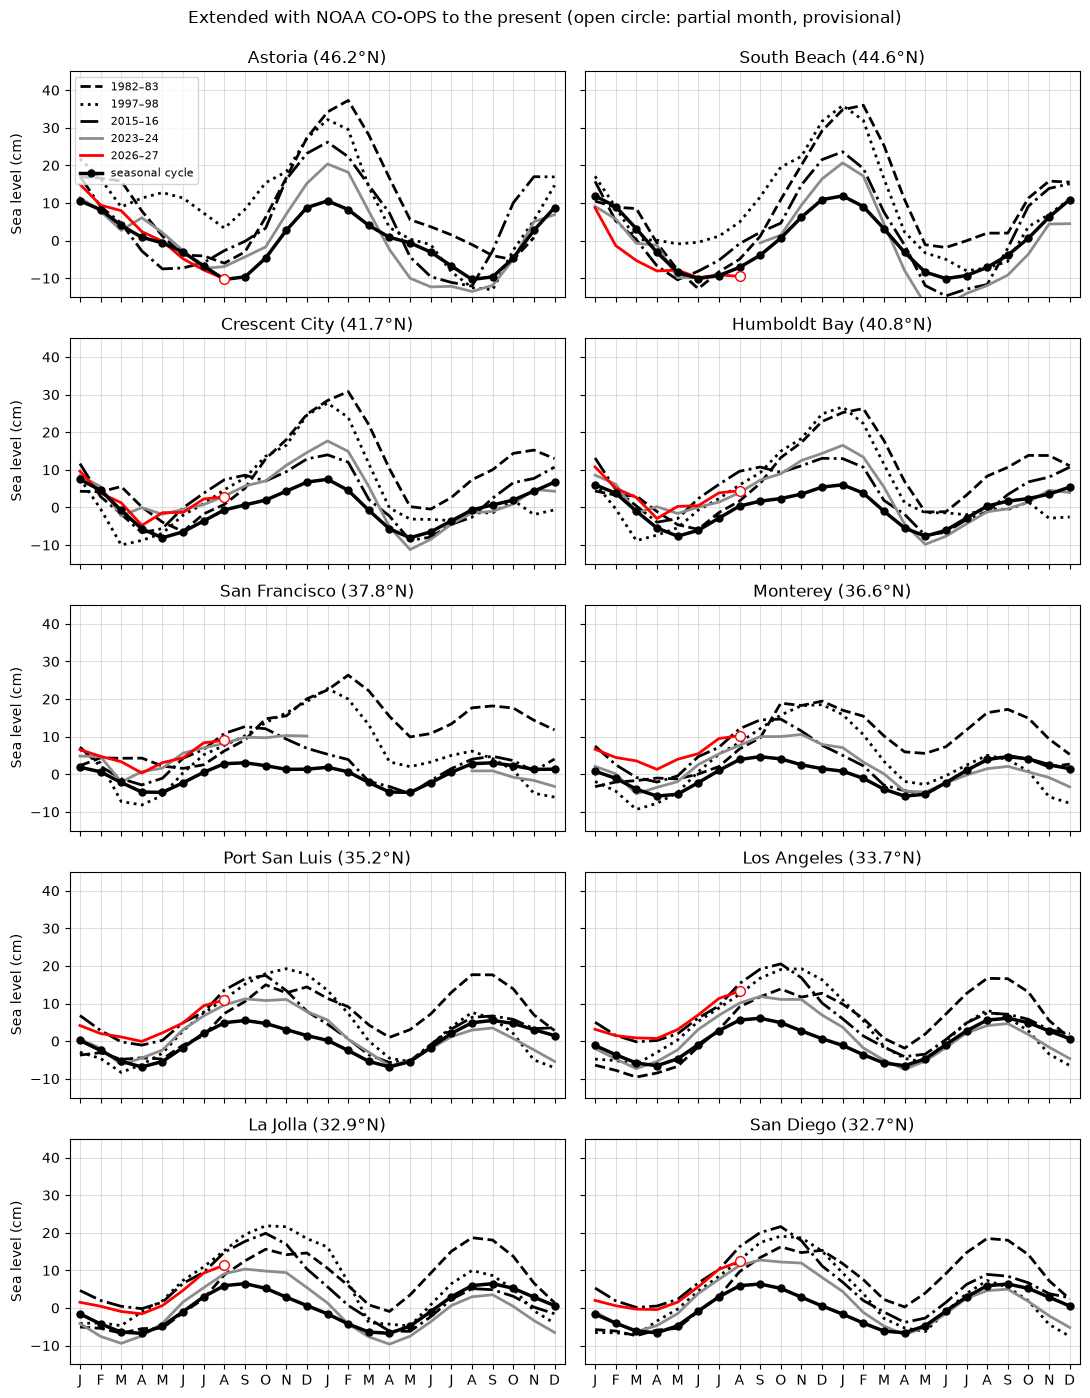

2026–27 so far, north to south (departure from each station's climatology):
  Astoria                     +0.2 cm in 2026-08 (provisional)
  South Beach                 -2.4 cm in 2026-08 (provisional)
  Crescent City               +3.5 cm in 2026-08 (provisional)
  Humboldt Bay                +4.0 cm in 2026-08 (provisional)
  San Francisco               +6.2 cm in 2026-08 (provisional)
  Monterey                    +6.3 cm in 2026-08 (provisional)
  Port San Luis               +6.0 cm in 2026-08 (provisional)
  Los Angeles                 +7.7 cm in 2026-08 (provisional)
  La Jolla                    +5.4 cm in 2026-08 (provisional)
  San Diego                   +6.4 cm in 2026-08 (provisional)


In [8]:
fig, axes = plt.subplots(5, 2, figsize=(11, 14), sharex=True, sharey=True)
for ax, rec in zip(axes.flat, records):
    plot_two_year_cycle(ax, rec["sl_ext"], f"{rec['name']} ({rec['lat']:.1f}°N)")
    if rec["partial_last"]:  # ring the provisional partial-month point
        window = two_year_window(rec["sl_ext"], 2026)
        last = np.where(~np.isnan(window))[0]
        if len(last):
            ax.plot(last[-1] + 1, window[last[-1]], "o", ms=7,
                    markerfacecolor="white", markeredgecolor="r", zorder=5)
handles, labels = axes.flat[0].get_legend_handles_labels()
axes.flat[0].legend(handles, labels, loc="upper left", fontsize=8)
for ax in axes[:, 0]:
    ax.set_ylabel("Sea level (cm)")
fig.suptitle("Extended with NOAA CO-OPS to the present "
             "(open circle: partial month, provisional)", y=0.995)
fig.tight_layout()
plt.show()

print("2026–27 so far, north to south (departure from each station's climatology):")
for rec in records:
    clim = seasonal_climatology(rec["sl_ext"])
    excess = two_year_window(rec["sl_ext"], 2026) - np.tile(clim.to_numpy(), 2)
    valid = np.where(~np.isnan(excess))[0]
    if not len(valid):
        continue
    i = valid[-1]
    print(f"  {rec['name']:<26} {excess[i]:+5.1f} cm in 2026-{i % 12 + 1:02d}"
          f"{' (provisional)' if rec['partial_last'] else ''}")

## 7. What to look for, and your assignment

Work through the grid from bottom (San Diego) to top (Astoria):

- **Phase of the seasonal maximum.** Late summer in Southern California, January from
  Humboldt Bay north, with the cycle flattening near the transition. The printed table
  gives the month and range for each station.
- **Where the El Niño pulse lands.** The event curves rise above the seasonal cycle
  from roughly October to February at every station. In the south that is months after
  the seasonal peak; at Crescent City and northward it lands on or near it.
- **Total water level.** The biggest excursions — nearly 40 cm in the 1982–83 and
  1997–98 winters — appear at the northern stations, where seasonal maximum and
  El Niño pulse stack. San Diego's largest monthly values are roughly half that.
- **The events differ.** 2023–24 was strong by tropical indices but modest in coastal
  sea level. A composite average would smear that distinction away — which is exactly
  why we plot the individual years first.
- **The current event.** With the CO-OPS extension every station now carries a red
  curve into August 2026. Where does it sit relative to the past events at the same
  stage, and at which stations is it climbing fastest?
- **Astoria sits inside the Columbia River mouth.** Its monthly means carry a
  discharge signal (spring freshet, winter runoff) on top of the ocean signal. Compare
  its shape against South Beach, 180 km south on the open coast: what differs, and is
  the difference where the hydrograph says it should be?

**In your groups:** each group takes one station, downloads it from the
[UHSLC data page](https://uhslc.soest.hawaii.edu/data/), reproduces the two-year plot,
and computes composite averages over the past events. Choose line styles that keep the
years distinguishable. We will compare stations at the end and assemble the alongshore
story together.

Questions worth arguing about while you work:

1. Detrending removes the century-scale rise, but 2015–16 arrived on top of the
   2014–15 North Pacific marine heatwave. Is the residual difference between 1997–98
   and 2015–16 an El Niño difference or a background-state difference? What plot
   would distinguish them?
2. The trend column in the table spans roughly −1 to +5 mm/yr along one coastline.
   Sea level rise is not the only thing in a tide gauge trend — what else moves?
3. Would you rather define the El Niño signal as a departure from the seasonal
   climatology or from the previous year? What breaks in each definition?

## Data provenance

- University of Hawaii Sea Level Center (UHSLC) daily tide gauge data, retrieved
  2026-08-13 from `https://uhslc.soest.hawaii.edu/data/netcdf/` (fast-delivery archive
  for active stations, research-quality archive for `d555a`, `d565a`, `d567a`,
  `d572a`, `d576a`).
- Dataset reference: Caldwell, P. C., M. A. Merrifield, and P. R. Thompson (2015),
  *Sea level measured by tide gauges from global oceans — the Joint Archive for Sea
  Level holdings*, NOAA NCEI, dataset doi:10.7289/V5V40S7W.
- Recent months: NOAA CO-OPS data API (`api.tidesandcurrents.noaa.gov`), verified
  monthly means plus preliminary 6-minute data for the current month, fetched at run
  time; station IDs in `COOPS_IDS`.
- Raw UHSLC files live in `data/raw/uhslc/` and stay out of Git, per the course data
  contract. The download cell above regenerates them from the provider.
- This notebook adapts M. Merrifield's `ElNinoEvents.m` / `ElNino_plots.m`
  (instructor copies in `instructor_notes/merrifield_elnino_matlab/`), converted to
  metric units, with the 2023–24 event and the CO-OPS extension added.